**Initialization**

The notebook has been tested using MI CPU DEL PORTATIL (i5-1035G1)

In [1]:
import os
import random
from matplotlib import pyplot as plt
import cv2

import numpy as np
import pandas as pd

import snntorch as snn
import torch

# Para crear dataloaders personalizados con TorchVision

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from snntorch import spikeplot as splt
from snntorch import spikegen

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
import itertools

# Para medir consumo energético

from codecarbon import EmissionsTracker


**Setting up train and test set under labels "human" and "AI"**

**Creating train set (NEW, para SNNTorch)**

In [2]:
transform_train = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_dataset = datasets.ImageFolder("../data_snn_flat/train/", transform=transform_train)
#train_dataset = datasets.ImageFolder("./data_snn_flat_reduced/train/", transform=transform_train)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


print("Total imágenes entrenamiento:", len(train_dataset))


Total imágenes entrenamiento: 155015


In [3]:
# Codigo para comprobar la forma del dataset
"""

for images, labels in train_loader:
    print(images.shape, labels.shape)
    break
"""

'\n\nfor images, labels in train_loader:\n    print(images.shape, labels.shape)\n    break\n'

**Creating the test set (NEW, para SNNTorch)**

In [4]:
transform_test = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

test_dataset = datasets.ImageFolder("../data_snn_flat/test/", transform=transform_test)
#test_dataset = datasets.ImageFolder("./data_snn_flat_reduced/test/", transform=transform_test)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)

print("Total imágenes test:", len(test_dataset))


Total imágenes test: 30000


In [5]:
# Codigo para comprobar la cantidad de imágenes y los tipos de estas
"""
print(len(train_dataset), len(test_dataset))
print(train_dataset.classes)
"""

'\nprint(len(train_dataset), len(test_dataset))\nprint(train_dataset.classes)\n'

**Mostramos los datos del dataset para ver que las imagenes están procesadas correctamente (y por curiosidad)**

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9529412].


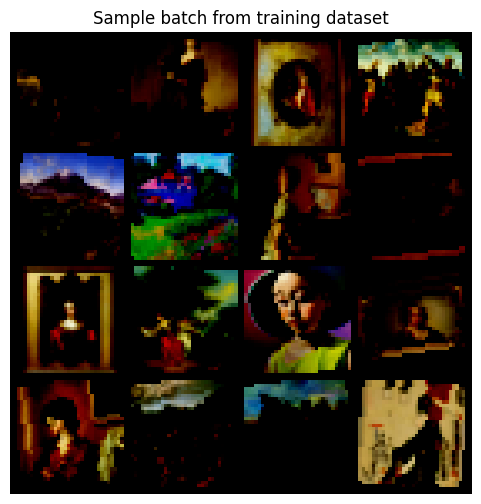

Labels: [1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0]
155015 30000


['AI', 'human']

In [6]:
# Comprobación de imágenes del dataset de entrenamiento ya transformadas
import matplotlib.pyplot as plt
import torchvision

data_iter = iter(train_loader)
images, labels = next(data_iter)

# Crea una cuadrícula automáticamente
img_grid = torchvision.utils.make_grid(images[:16], nrow=4, padding=2)
img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(6, 6))
plt.imshow(img_grid)
plt.title("Sample batch from training dataset")
plt.axis("off")
plt.show()

print("Labels:", labels[:16].tolist())

####     0 = AI           1 = humano

print(len(train_dataset), len(test_dataset))

train_dataset.classes

**Building the neural network**

In [7]:
#### Basado en el ejemplo de : https://snntorch.readthedocs.io/en/latest/examples/example_snn/example_snn_lapicque1.html

import torch
import torch.nn as nn
import snntorch as snn
import snntorch.functional as SF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Parámetros

R = 1
C = 1.44

num_inputs = 3072 # 32 * 32 * 3
num_hidden = 1000
num_outputs = 2

beta = 0.95
threshold = 0.3
num_steps = 100

batch_size = 64
dtype = torch.float


# Definir la red:

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize layers
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta)

    def forward(self, x):
        
        # Cambio con respecto al original!!
        # Esta linea aplana, manteniendo x con el mismo batch_size que x, pero aplana
        # las otras 3 en una sola (32x32x3 -> 3072)

        x = x.view(x.size(0), -1)

        # Initialize hidden states at t=0
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        # Record the final layer
        spk2_rec = []
        mem2_rec = []

        for step in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)


net = Net().to(device)

# print(net(data.view(batch_size, -1)))
# Este print no funciona porque data no está definido.
# Ya que la variable data pertenece a MNIST
# En nuestro caso habría que hacer :

data, targets = next(iter(train_loader))
data = data.to(device)

#data = data.view(data.size(0), -1)

spk_rec, mem_rec = net(data)

# La forma de la red es [num_steps, buffer_size, num_clases]
print("Spikes shape:", spk_rec.shape)
print("Membrane potentials shape:", mem_rec.shape)



Device: cpu
Spikes shape: torch.Size([100, 64, 2])
Membrane potentials shape: torch.Size([100, 64, 2])


**Training neural network (NEW, para SNNTorch)**

In [8]:
# pass data into the network, sum the spikes over time
# and compare the neuron with the highest number of spikes
# with the target

def print_batch_accuracy(data, targets, train=False):
    output, _ = net(data)
    _, idx = output.sum(dim=0).max(1)
    acc = np.mean((targets == idx).detach().cpu().numpy())

    if train:
        print(f"Train set accuracy for a single minibatch: {acc*100:.2f}%")
    else:
        print(f"Test set accuracy for a single minibatch: {acc*100:.2f}%")

def train_printer(
    data, targets, epoch,
    counter, iter_counter,
        loss_hist, test_loss_hist, test_data, test_targets):
    print(f"Epoch {epoch}, Iteration {iter_counter}")
    print(f"Train Set Loss: {loss_hist[-1]:.2f}")
    print(f"Test Set Loss: {test_loss_hist[counter]:.2f}")
    print_batch_accuracy(data, targets, train=True)
    print_batch_accuracy(test_data, test_targets, train=False)
    print("\n")
    

**Inicialización del loss y del optimizer**

In [9]:
# Variable lr = learning rate. Modificable para dar más o menos saltos a la hora de ajustar
optimizer = torch.optim.Adam(net.parameters(), lr=5e-5, betas=(0.9, 0.999))


**Train loop separado y sin loop**

In [10]:
# 1 iteración de prueba con prints a cada paso para debugear

"""

num_steps = 25

# 1º Cogemos los datos y los targets a mano (luego lo hará el bucle for) y los metemos en el device
print("Comenzando primer paso\n\n")

data, targets = next(iter(train_loader))
data = data.to(device)
targets = targets.to(device)

# 2º Aplanamos los datos de entrada al tamaño del vector, y los metemos en la red
print("\n\nComenzando segundo paso\n\n")

# Linea original : spk_rec, mem_rec = net(data.view(batch_size, -1))
# Cambiamos el -1 por el tamaño de nuestro dataset hardcodeado, aun no entiendo por qué -1 no lo pilla automaticamente

# Lo que hacemos aqui es obtener los spikes (spk_rec) y los potenciales de membrana (mem_rec)
#  a través de lo que nos da el loader de entrenamiento metido en la net
spk_rec, mem_rec = net(data.view(batch_size, 3,32,32))
print(mem_rec.size())

# 3º Ahora inicializamos la perdida a ceros, luego sumamos en loss_val el cálculo de la pérdida en cada uno de los 10 steps
print("\n\nComenzando tercer paso\n\n")

# initialize the total loss value
loss_val = torch.zeros((1), dtype=dtype, device=device)

# El cálculo de la pérdida se hace mediante la función loss "CrossEntropyLoss" declarada antes
# Los parametros necesarios son "mem_rec[step]"
# sum loss at every step
for step in range(num_steps):
  loss_val += loss(mem_rec[step], targets)

print(f"Training loss: {loss_val.item():.3f}")


# 4º Mostramos la pérdida que hemos tenido en estos 10 steps. La accuracy tambien será baja porque estamos con un modelo sin entrenar
print("\n\nComenzando cuarto paso\n\n")

print_batch_accuracy(data, targets, train=True)


# 5º Actualizamos los pesos una vez en la red
print("\n\nComenzando quinto paso\n\n")

# clear previously stored gradients
optimizer.zero_grad()

# calculate the gradients
loss_val.backward()

# weight update
optimizer.step()


# 6º Ahora rehacemos el calculo de la perdida y de la accuaricy en una iteracion
print("\n\nComenzando sexto paso\n\n")

# calculate new network outputs using the same data
# Cambiamos el -1 por el tamaño de nuestro dataset hardcodeado igual que antes
spk_rec, mem_rec = net(data.view(batch_size, 3,32,32))

# initialize the total loss value
loss_val = torch.zeros((1), dtype=dtype, device=device)

# sum loss at every step
for step in range(num_steps):
  loss_val += loss(mem_rec[step], targets)

# 7º Por último imprimimos el loss y luego la accuracy con 
print("\n\nComenzando septimo paso\n\n")

print(f"Training loss: {loss_val.item():.3f}")
print_batch_accuracy(data, targets, train=True)

"""


'\n\nnum_steps = 25\n\n# 1º Cogemos los datos y los targets a mano (luego lo hará el bucle for) y los metemos en el device\nprint("Comenzando primer paso\n\n")\n\ndata, targets = next(iter(train_loader))\ndata = data.to(device)\ntargets = targets.to(device)\n\n# 2º Aplanamos los datos de entrada al tamaño del vector, y los metemos en la red\nprint("\n\nComenzando segundo paso\n\n")\n\n# Linea original : spk_rec, mem_rec = net(data.view(batch_size, -1))\n# Cambiamos el -1 por el tamaño de nuestro dataset hardcodeado, aun no entiendo por qué -1 no lo pilla automaticamente\n\n# Lo que hacemos aqui es obtener los spikes (spk_rec) y los potenciales de membrana (mem_rec)\n#  a través de lo que nos da el loader de entrenamiento metido en la net\nspk_rec, mem_rec = net(data.view(batch_size, 3,32,32))\nprint(mem_rec.size())\n\n# 3º Ahora inicializamos la perdida a ceros, luego sumamos en loss_val el cálculo de la pérdida en cada uno de los 10 steps\nprint("\n\nComenzando tercer paso\n\n")\n\n# 

**Train loop completo y comentado**

In [ ]:
from collections import Counter
# Como la cantidad de imágenes IA está descompensado con respecto a las humanas, vamos
# a darle más peso a los errores en la clase humana
counts = Counter(train_dataset.targets)
class_counts = torch.tensor([counts[i] for i in range(len(train_dataset.classes))], dtype=torch.float)

print("Clases:", train_dataset.classes)
print("Conteo:", class_counts)

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * 2
class_weights = class_weights.to(device)
loss = torch.nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
from codecarbon import EmissionsTracker

num_epochs = 10
epoch = 0
loss_hist = []
test_loss_hist = []
val_accuracy_hist = []
counter = 0

# Metricas por epoch

epoch_loss_hist = []
epoch_test_loss_hist = []
epoch_acc_hist = []

# Funcion para obtener la accuracy por epoch

def accuracy(mem, targets):
    preds = mem.argmax(dim=1)
    return (preds == targets).float().mean().item() * 100

def train():
    global counter

    tracker = EmissionsTracker(
        log_level="error",
        save_to_file=True,
        output_dir="../Consumo",
        output_file="emissions_snn.csv",
        measure_power_secs=1
    )
    tracker.start()

    for epoch in range(num_epochs):

        iter_counter = 0

        epoch_loss = 0
        epoch_test_loss = 0
        epoch_acc = 0
        num_batches = 0
        num_test_batches = 0

        # Por cada epoch, volvemos a iniciar el iter counter y el train_batch, es decir, el contador
        # de cuantas imagenes ha visto, y el conjunto de imagenes + su predicción que sería correcta

        iter_counter = 0
        train_batch = iter(train_loader)
        test_iterator = iter(test_loader)

        # Reiniciamos los contadores de metricas por epoch

        epoch_test_loss = 0
        epoch_acc = 0
        num_batches = 0

        # TRAIN

        # Activamos el modo entrenamiento, lo que hace cosas como por ejemplo, el dropout (apagar neuronas mientras entrena para evitar estancamiento)

        net.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for i, (data, targets) in enumerate(train_batch):

            # Metemos los datos, es decir, las fotos, en la variable data, y  metemos las predicciones correctas en la variable targets

            data = data.to(device)
            targets = targets.to(device)

            # forward pass, es decir, calcular las salidas spk y mem

            # 1º Limpiamos gradientes de la iteración anterior
            optimizer.zero_grad()


            # 2º Ejecuta el forward pasando por parámetro los datos y por cada step, 
            # introduce la información en las capas y devuelve spikes y potencial de membrana
            spk_rec, mem_rec = net(data)
            num_steps = mem_rec.size(0)


            # Inicializamos la pérdida (loss) y luego sumamos sobre cada step que hemos hecho (la variable num_steps es la misma en la declaración de la net y la que hay ahora, o debería)
            loss_val = 0
            for step in range(num_steps):
                loss_val = loss_val + loss(mem_rec[step], targets)
                (mem_rec[step], targets)

            # Finalmente promediamos con:

            loss_val = loss_val / num_steps

            # Retropropagamos la pérdida calculada, es decir, calculamos el gradiente del error que hemos tenido 
            # con respecto a la net aplicando las reglas matemáticas de cálculo de derivadas automaticamente, en el
            # grafo " data → fc → lif → ... → mem_rec → loss " para finalmente almacenarlos en las respectivas capas,
            # por ejemplo en : net.fc1.weight.grad

            loss_val.backward()

            # En este peso utilizamos los pesos calculados en loss_val.backward() para aplicarlos

            optimizer.step()

            # Para que se muestre en pantalla lo último aplicado y ver como va cambiando

            loss_hist.append(loss_val.item())

            running_loss += loss_val.item()


            epoch_loss += loss_val.item()
            num_batches += 1

            _, predicted = torch.max(mem_rec[-1], 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

            if i % 25 == 0:
                print(f"Epoch {epoch}, Iteration {i} - Loss: {running_loss/(i+1):.4f} Accuracy: {100*correct/total:.2f}%")
        
        # Guardamos valor del loss por epoch del entrenamiento
        epoch_loss_hist.append(epoch_loss / num_batches)

        

        # TEST


        # Bucle test, para ver como de preciso (accuracy) ha sido en la última epoch de entrenamineto
        # with torch.no_grad(): hace que todo lo que se ejecute en su interor no guarda gradientes,
        # así que no se puede hacerle backward, pero es más barato y no actualiza nada. Perfecto para eval


        # Ahora lo ponemos en modo evaluación. El equivalente a net.train()

        net.eval()

        with torch.no_grad():

            for test_data, test_targets in test_loader:

                # Ahora sacamos del iterador de test las fotos (test_data) y la label correcta (test_targets)
                # y los cargamos en el device

                test_data = test_data.to(device)
                test_targets = test_targets.to(device)

                # Ejecuta el forward pasando por parámetro los datos y por cada step, 
                # introduce la información en las capas y devuelve spikes y potencial de membrana
                # (Exactamente lo mismo que con train_spk y train_mem, solo que esta vez no actualiza nada)

                test_spk, test_mem = net(test_data)

                # Inicializamos la pérdida (loss) y luego sumamos sobre cada step que hemos hecho (la variable 
                # num_steps es la misma en la declaración de la net y la que hay ahora, o debería)

                test_loss = 0
                for step in range(num_steps):
                    test_loss += loss(test_mem[step], test_targets)
                
                test_loss = test_loss / num_steps

                test_loss_hist.append(test_loss.item())

                print(f"Test loss : {test_loss.item()}")

                epoch_test_loss += test_loss.item()

                # Ahora calculamos la precisión (accuracy) con los potenciales de membrana y los targets

                # He cambiado esta linea, concretamente el primer parametro en la funcion accuracy, ya que antes
                # solo se pasaba el último spike. Ahora se pasa la membrana

                val_acc = accuracy(test_mem[-1], test_targets)

                # Guardamos el valor de accuracy por batch del test
                val_accuracy_hist.append(val_acc)


                epoch_acc += val_acc
                num_test_batches += 1

                # Cada 50 iteraciones de test mostramos los datos relevantes. Esto no tiene mas chicha que la muestra de
                # datos más precisa.

                if counter % 50 == 0:
                    train_printer(
                        data, targets, epoch,
                        counter, iter_counter,
                        loss_hist, test_loss_hist,
                        test_data, test_targets)
                counter += 1
                iter_counter +=1
   
        # Guardamos las métricas de loss y accuracy promediados por epoch del test
        epoch_test_loss_hist.append(epoch_test_loss / num_test_batches)
        epoch_acc_hist.append(epoch_acc / num_test_batches)

    torch.save({
        'epoch': epoch,
        'model_state_dict': net.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss_hist': loss_hist,
        'test_loss_hist': test_loss_hist,
        'val_accuracy_hist': val_accuracy_hist,
        'epoch_loss_hist': epoch_loss_hist,
        'epoch_test_loss_hist': epoch_test_loss_hist,
        'epoch_acc_hist': epoch_acc_hist,
    }, '../Modelos_Guardados/checkpoint_snn.pth')

    # Terminamos la medicion

    emissions = tracker.stop()
    print(f"Emisiones de CO₂ (kg): {emissions}")       


train()

[codecarbon WARNING @ 00:22:49] Multiple instances of codecarbon are allowed to run at the same time.
/home/robotcgb/Documentos/AI-Artbench/venvArtbench/lib/python3.11/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 0, Iteration 0 - Loss: 0.9021 Accuracy: 40.62%
Epoch 0, Iteration 25 - Loss: 0.6131 Accuracy: 57.87%
Epoch 0, Iteration 50 - Loss: 0.5945 Accuracy: 58.79%
Epoch 0, Iteration 75 - Loss: 0.5618 Accuracy: 61.14%
Epoch 0, Iteration 100 - Loss: 0.5326 Accuracy: 62.86%
Epoch 0, Iteration 125 - Loss: 0.5172 Accuracy: 64.34%
Epoch 0, Iteration 150 - Loss: 0.4981 Accuracy: 65.73%
Epoch 0, Iteration 175 - Loss: 0.4873 Accuracy: 66.61%
Epoch 0, Iteration 200 - Loss: 0.4803 Accuracy: 67.07%
Epoch 0, Iteration 225 - Loss: 0.4715 Accuracy: 67.68%
Epoch 0, Iteration 250 - Loss: 0.4675 Accuracy: 67.77%
Epoch 0, Iteration 275 - Loss: 0.4620 Accuracy: 68.25%
Epoch 0, Iteration 300 - Loss: 0.4566 Accuracy: 68.78%
Epoch 0, Iteration 325 - Loss: 0.4534 Accuracy: 69.09%
Epoch 0, Iteration 350 - Loss: 0.4499 Accuracy: 69.45%
Epoch 0, Iteration 375 - Loss: 0.4450 Accuracy: 69.93%
Epoch 0, Iteration 400 - Loss: 0.4419 Accuracy: 70.06%
Epoch 0, Iteration 425 - Loss: 0.4404 Accuracy: 70.22%
Epoch 0, Iterat

In [23]:
torch.save({
    'epoch': epoch,
    'model_state_dict': net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss_hist': loss_hist,
    'test_loss_hist': test_loss_hist,
    'val_accuracy_hist': val_accuracy_hist,
    'epoch_loss_hist': epoch_loss_hist,
    'epoch_test_loss_hist': epoch_test_loss_hist,
    'epoch_acc_hist': epoch_acc_hist,
}, '../Modelos_Guardados/checkpoint_snn.pth')

In [ ]:
from codecarbon import EmissionsTracker

num_epochs = 10
counter = 0

def accuracy(mem, targets):
    preds = mem.argmax(dim=1)
    return (preds == targets).float().mean().item() * 100


# Cargamos el checkpoint para reanudar el entrenamiento

checkpoint = torch.load('../Modelos_Guardados/checkpoint_snn.pth', map_location=device)

net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

loss_hist = checkpoint['loss_hist']
test_loss_hist = checkpoint['test_loss_hist']
val_accuracy_hist = checkpoint['val_accuracy_hist']
epoch_loss_hist = checkpoint['epoch_loss_hist']
epoch_test_loss_hist = checkpoint['epoch_test_loss_hist']
epoch_acc_hist = checkpoint['epoch_acc_hist']

start_epoch = checkpoint['epoch'] + 1


def train():
    global counter

    tracker = EmissionsTracker(
        log_level="error",
        save_to_file=True,
        output_dir="../Consumo",
        output_file="emissions_snn.csv",
        measure_power_secs=1
    )
    tracker.start()

    for epoch in range(start_epoch, num_epochs):

        iter_counter = 0

        epoch_loss = 0
        epoch_test_loss = 0
        epoch_acc = 0
        num_batches = 0
        num_test_batches = 0

        train_batch = iter(train_loader)
        test_iterator = iter(test_loader)

        # TRAIN

        net.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for i, (data, targets) in enumerate(train_batch):

            data = data.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            spk_rec, mem_rec = net(data)
            num_steps = mem_rec.size(0)

            loss_val = 0
            for step in range(num_steps):
                loss_val = loss_val + loss(mem_rec[step], targets)

            loss_val = loss_val / num_steps

            loss_val.backward()
            optimizer.step()

            loss_hist.append(loss_val.item())

            running_loss += loss_val.item()

            epoch_loss += loss_val.item()
            num_batches += 1

            _, predicted = torch.max(mem_rec[-1], 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

            if i % 25 == 0:
                print(f"Epoch {epoch}, Iteration {i} - Loss: {running_loss/(i+1):.4f} Accuracy: {100*correct/total:.2f}%")

        epoch_loss_hist.append(epoch_loss / num_batches)

        # TEST

        net.eval()

        with torch.no_grad():

            for test_data, test_targets in test_loader:

                test_data = test_data.to(device)
                test_targets = test_targets.to(device)

                test_spk, test_mem = net(test_data)

                test_loss = 0
                for step in range(num_steps):
                    test_loss += loss(test_mem[step], test_targets)

                test_loss = test_loss / num_steps

                test_loss_hist.append(test_loss.item())

                epoch_test_loss += test_loss.item()

                val_acc = accuracy(test_mem[-1], test_targets)
                val_accuracy_hist.append(val_acc)

                epoch_acc += val_acc
                num_test_batches += 1
                counter += 1
                iter_counter += 1

        epoch_test_loss_hist.append(epoch_test_loss / num_test_batches)
        epoch_acc_hist.append(epoch_acc / num_test_batches)

        avg_test_loss = epoch_test_loss / num_test_batches
        print(f"[TEST] Epoch {epoch} - Loss: {avg_test_loss:.4f} Acc: {epoch_acc / num_test_batches:.2f}%")

    emissions = tracker.stop()
    print(f"Emisiones de CO₂ (kg): {emissions}")


train()

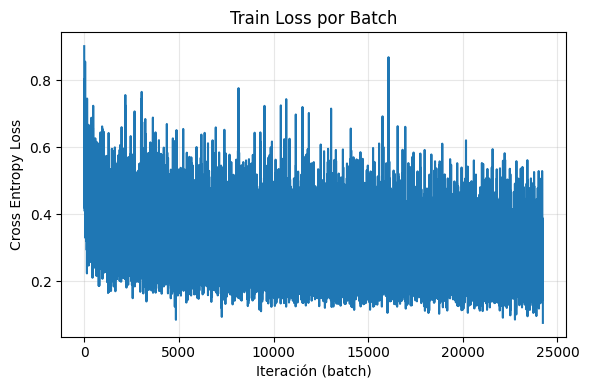

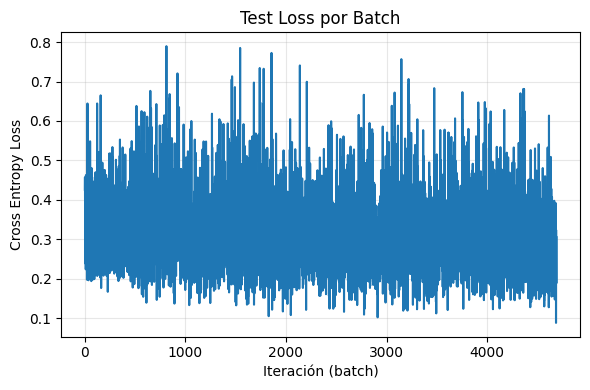

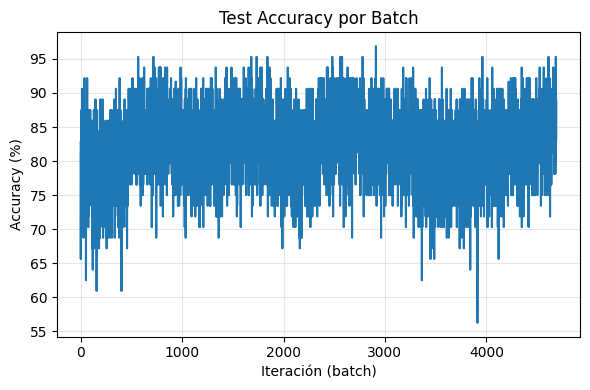

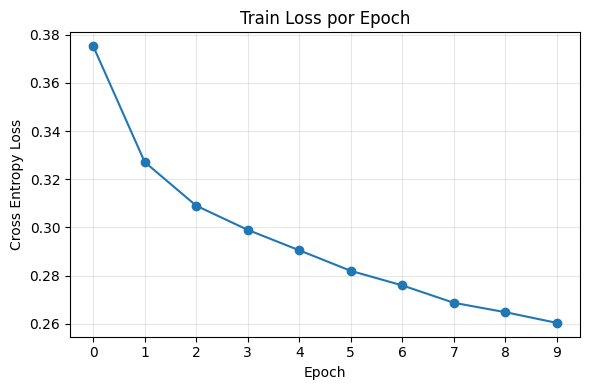

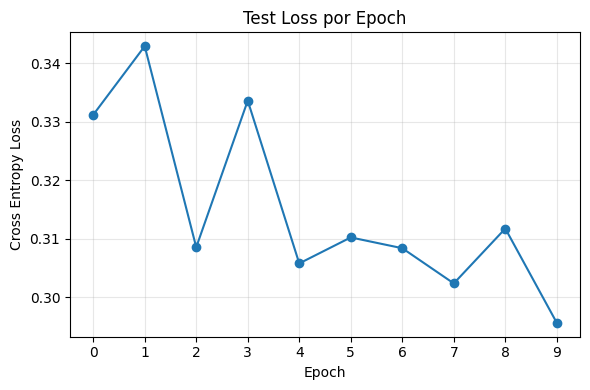

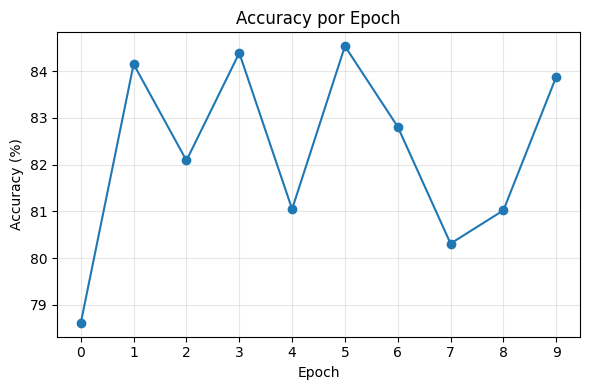

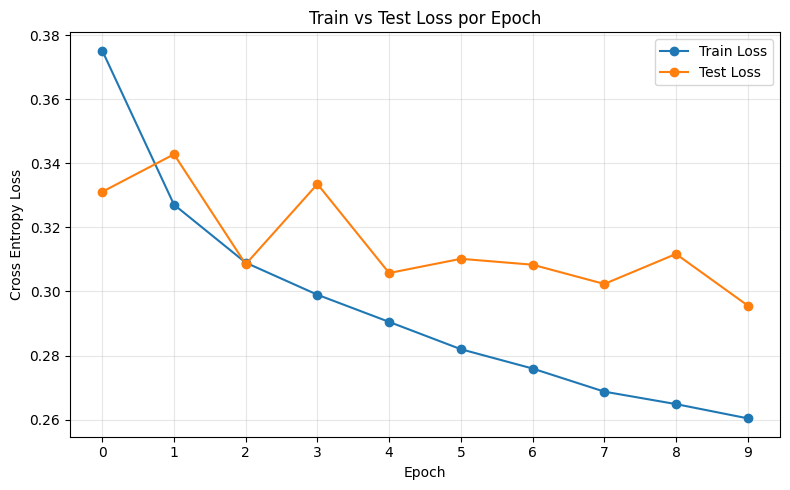

In [13]:
import matplotlib.pyplot as plt

# GRÁFICAS NIVEL BATCH

import matplotlib.pyplot as plt

# Train Loss por batch
plt.figure(figsize=(6, 4))
plt.plot(loss_hist)
plt.title("Train Loss por Batch")
plt.xlabel("Iteración (batch)")
plt.ylabel("Cross Entropy Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/SNN/train_loss_batch.png", dpi=150)
plt.show()


# Test Loss por batch
plt.figure(figsize=(6, 4))
plt.plot(test_loss_hist)
plt.title("Test Loss por Batch")
plt.xlabel("Iteración (batch)")
plt.ylabel("Cross Entropy Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/SNN/test_loss_batch.png", dpi=150)
plt.show()


# Test Accuracy por batch
plt.figure(figsize=(6, 4))
plt.plot(val_accuracy_hist)
plt.title("Test Accuracy por Batch")
plt.xlabel("Iteración (batch)")
plt.ylabel("Accuracy (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/SNN/test_accuracy_batch.png", dpi=150)
plt.show()

# GRÁFICAS NIVEL EPOCH

epochs_range = range(len(epoch_loss_hist))

# Train Loss por epoch
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, epoch_loss_hist, marker='o')
plt.title("Train Loss por Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.xticks(epochs_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/SNN/train_loss_epoch.png", dpi=150)
plt.show()


# Test Loss por epoch
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, epoch_test_loss_hist, marker='o')
plt.title("Test Loss por Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.xticks(epochs_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/SNN/test_loss_epoch.png", dpi=150)
plt.show()


# Accuracy por epoch
epochs_range_acc = range(len(epoch_acc_hist))

plt.figure(figsize=(6, 4))
plt.plot(epochs_range_acc, epoch_acc_hist, marker='o')
plt.title("Accuracy por Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(epochs_range_acc)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/SNN/accuracy_epoch.png", dpi=150)
plt.show()

# COMPARATIVA TRAIN vs TEST LOSS POR EPOCH (superpuesto)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, epoch_loss_hist, marker='o', label="Train Loss")
plt.plot(epochs_range, epoch_test_loss_hist, marker='o', label="Test Loss")
plt.title("Train vs Test Loss por Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.xticks(epochs_range)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Graficas/SNN/train_vs_test_loss.png", dpi=150)
plt.show()

**Evaluating the network**

In [2]:
#history.history.keys()
# El equivalente sería a utilizar loss_hist y test_loss_hist

In [1]:
import torch
from codecarbon import EmissionsTracker

def evaluate_snn_energy(model, test_loader, device):

    model.eval()

    correct = 0
    total = 0

    tracker = EmissionsTracker(
        log_level="error",
        output_file="emissions_snn_inference.csv",
        measure_power_secs=1
    )

    tracker.start()

    with torch.no_grad():
        for data, targets in test_loader:
            data = data.to(device)
            targets = targets.to(device)

            spk_rec, mem_rec = model(data)

            outputs = mem_rec[-1]

            _, predicted = torch.max(outputs, 1)

            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    emissions = tracker.stop()

    accuracy = 100 * correct / total

    print(f"Accuracy: {accuracy:.2f}%")
    print(f"Energía consumida (kWh aprox): {emissions}")

    return accuracy, emissions

In [23]:
model = NetTutorial5().to(device)
evaluate_snn_energy(model, test_loader, device)

[codecarbon WARNING @ 21:29:25] Multiple instances of codecarbon are allowed to run at the same time.


KeyboardInterrupt: 

**GRAFICANDO**

In [17]:
fig = plt.figure(facecolor="w", figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

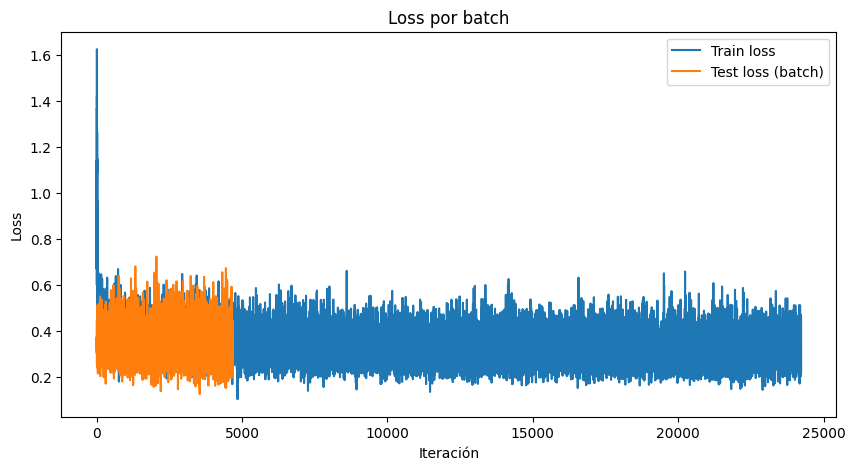

In [18]:
plt.figure(figsize=(10,5))
plt.plot(loss_hist)
plt.plot(test_loss_hist)
plt.title("Loss por batch")
plt.xlabel("Iteración")
plt.ylabel("Loss")
plt.legend(["Train loss", "Test loss (batch)"])
plt.show()

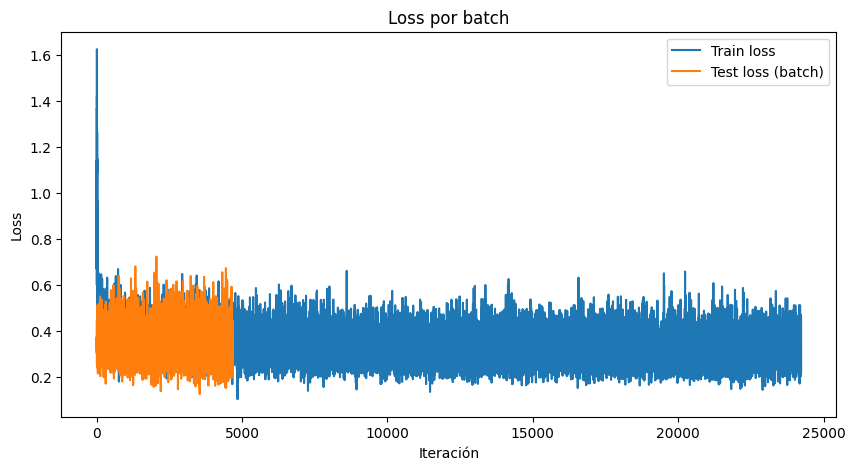

In [19]:
plt.figure(figsize=(10,5))
plt.plot(loss_hist)
plt.plot(test_loss_hist)
plt.title("Loss por batch")
plt.xlabel("Iteración")
plt.ylabel("Loss")
plt.legend(["Train loss", "Test loss (batch)"])
plt.show()

In [20]:
plt.figure(figsize=(10,5))
plt.plot(epoch_acc_hist)
plt.title("Validation Accuracy por epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

NameError: name 'epoch_acc_hist' is not defined

<Figure size 1000x500 with 0 Axes>

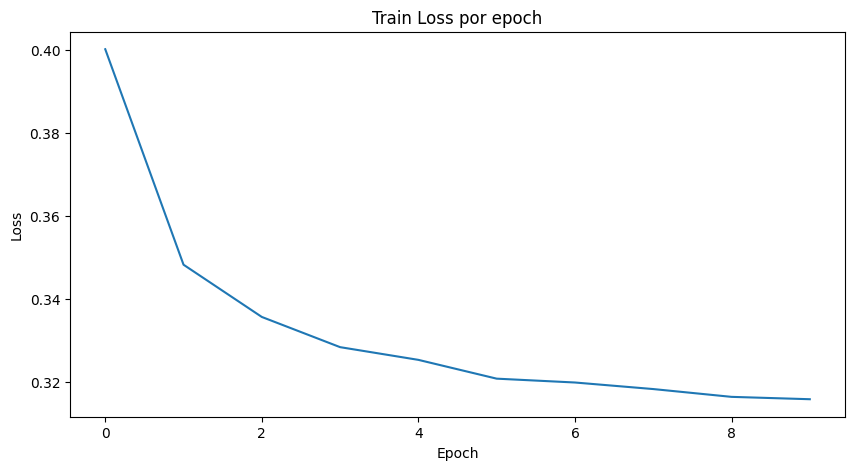

In [16]:
plt.figure(figsize=(10,5))
plt.plot(epoch_loss_hist)
plt.title("Train Loss por epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

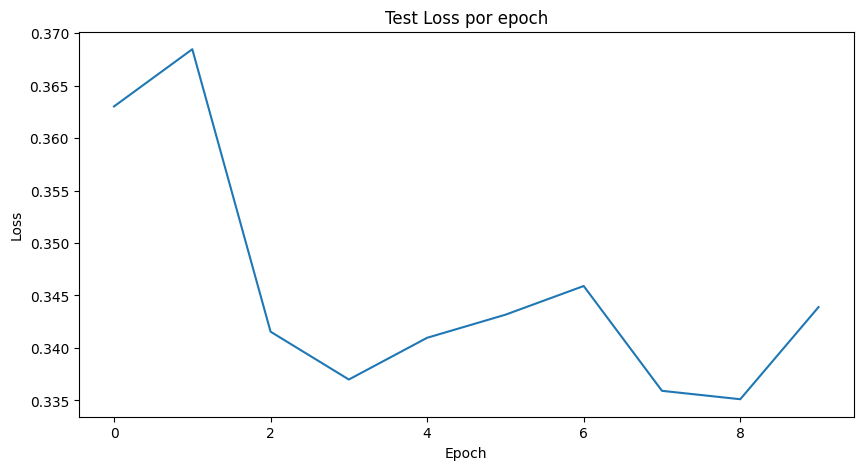

In [18]:
plt.figure(figsize=(10,5))
plt.plot(epoch_test_loss_hist)
plt.title("Test Loss por epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

**GRAFICADO OLD**

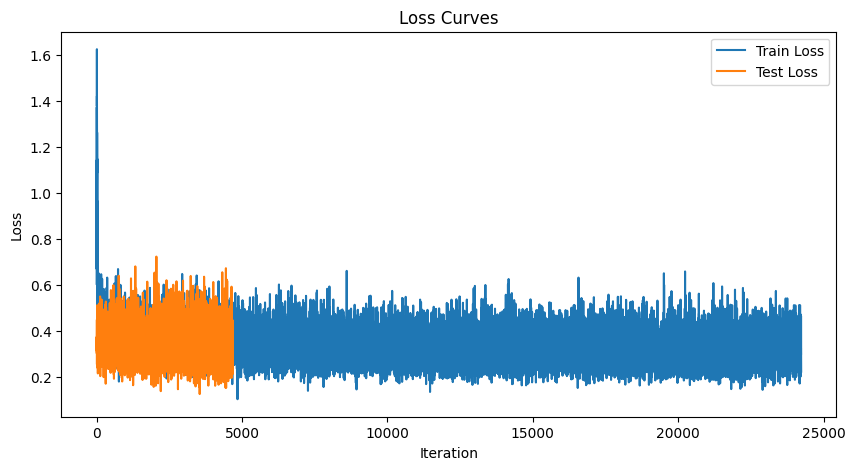

In [25]:
fig = plt.figure(facecolor="w", figsize=(10, 5))
plt.plot(loss_hist)
plt.plot(test_loss_hist)
plt.title("Loss Curves")
plt.legend(["Train Loss", "Test Loss"])
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

In [ ]:
plt.plot(epoch_loss_hist)
plt.title("Train Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

NameError: name 'epoch_loss_hist' is not defined

In [ ]:
import matplotlib.pyplot as plt
plt.plot(test_loss_hist)
plt.xlabel('Minibatch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss over Minibatches')
plt.show()

In [ ]:
# plt.plot(history.history['val_accuracy']);
# Keras guardaba este dato por si solo, pero ahora hay que guardarlo a mano si queremos verlo aquí
plt.plot(val_accuracy_hist)
plt.xlabel('Minibatch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy over Minibatches')
plt.show()

In [ ]:
# plt.plot(history.history['val_accuracy']);
# Keras guardaba este dato por si solo, pero ahora hay que guardarlo a mano si queremos verlo aquí
plt.plot(epoch_val_acc) # Aqui añadiremos algo que se creará a la hora de entrenar llamado val_accuracy justo después de hacer el test para guardar lo bien que va
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy over Epochs')
plt.show()

In [1]:
#predictions = net.predict(test_dataset)
#predictions
def predict_dataset(model, test_loader, device):
    model.eval()
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for data, targets in test_loader:
            data = data.to(device)
            
            # Forward pass
            spk_rec, mem_rec = model(data)
            
            # Rate coding: suma de spikes en el tiempo
            spike_counts = spk_rec.sum(dim=0)  # (batch_size, num_classes)
            
            # Predicción: neurona con más spikes
            _, predicted = spike_counts.max(1)
            
            all_predictions.append(predicted.cpu())
            all_targets.append(targets)
    
    # Concatenar todas las predicciones
    predictions = torch.cat(all_predictions)
    targets = torch.cat(all_targets)
    
    return predictions, targets

# USO:
predictions, true_labels = predict_dataset(net, test_loader, device)
print(f"Predicciones: {predictions[:10]}")
print(f"Labels reales: {true_labels[:10]}")

NameError: name 'net' is not defined

In [ ]:
predictions = np.argmax(predictions, axis = 1)
predictions

In [ ]:
#import seaborn as sns 
#from sklearn.metrics import confusion_matrix, classification_report
#cm = confusion_matrix(test_dataset.classes, predictions)
#sns.heatmap(cm, annot=True)
#print(classification_report(test_dataset.classes, predictions))

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix and classification report
cm = confusion_matrix(test_dataset.classes, predictions)
report = classification_report(test_dataset.classes, predictions)

# Define custom labels for the axes
labels = ['AI', 'Human']
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# Plot confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')

# Add labels to the axes
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# Print classification report
print(report)

# Show the plot
plt.show()


**Optional: Saving the model network and weights seperately**

In [ ]:
model_json = network.to_json()
with open('network.json','w') as json_file:
  json_file.write(model_json) #save network json

from keras.models import save_model
network_saved = save_model(network, '/kaggle/working/weights.hdf5') 